In [7]:
import json

import seaborn as sns
sns.set_style("darkgrid")

import pandas as pd

In [8]:
import IPython.display as display

In [9]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style="darkgrid")
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10

In [10]:
# CONFIGURATION
# =============
# Add/remove LLMs here.
LLMS = [
    {'name': 'Mistral-7B-v0.1',              'pretty': 'Mistral-7B-v0.1',              'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Llama-8B', 'pretty': 'DeepSeek-R1-Distill-Llama-8B', 'num_layers': 32},
    {'name': 'Qwen3-8B',                     'pretty': 'Qwen3-8B',                     'num_layers': 36},
    {'name': 'Llama-2-7b-hf',                'pretty': 'Llama-2-7b-hf',                'num_layers': 32},
    {'name': 'OLMo-2-1124-7B-Instruct',      'pretty': 'OLMo-2-1124-7B-Instruct',      'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Qwen-7B',  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',  'num_layers': 28},
    {'name': 'Llama-3.1-8B-Instruct',        'pretty': 'Llama-3.1-8B-Instruct',        'num_layers': 32},
]

# Specify the probing setting
PROBE_SETTING = 'dec_sci_compare'  # e.g., 'dec_dec_compare', 'int_sci_compare'

# Offsets for each probe type
OFFSET_REGRESSION = 'mixed_offset_0'       # e.g., 'mixed_offset_0', 'int_offset_0', 'sci_offset_0' for int-sci comparison
OFFSET_CLASSIFICATION = 'last_token'       # e.g., 'last_token', 'concat_offset_0'

# Where to save figures
SAVE_FIG_PATH = '../figures/'

# Which split to use
SPLIT = 'val'

# Which verbalization setting to use (should match PROBE_SETTING)
VERBALIZATION_SETTING = PROBE_SETTING


# 1. Loading Data

In [11]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def get_verbalization_results(llm, setting, alt=False):
    """Load verbalization results for a given LLM and setting."""
    path = os.path.join(
        "..",
        "verbalization-test" + ("-alt" if alt else ""),
        f"{llm}",
        f"{setting}.jsonl"
    )
    if not os.path.exists(path):
        print(f'Warning: {path} not found!')
        return None
    with open(path, 'r') as f:
        results = [json.loads(line) for line in f]
    return results


In [13]:
# Load all results
verbalization_results = {}
verbalization_results_alt = {}

for llm in LLMS:
    name = llm['name']
    verbalization_results[name] = get_verbalization_results(name, VERBALIZATION_SETTING)
    verbalization_results_alt[name] = get_verbalization_results(name, VERBALIZATION_SETTING, alt=True)


In [14]:
dfs = {name: pd.DataFrame(results[2:]) for name, results in verbalization_results.items()}
altdfs = {name: pd.DataFrame(results[2:]) for name, results in verbalization_results_alt.items()}

for model, df in dfs.items():
    df['model'] = model
    df['alt'] = False

for model, df in altdfs.items():
    df['model'] = model
    df['alt'] = True


In [15]:
df = pd.concat([*dfs.values(), *altdfs.values()])

# 2. Extracting various information

In [16]:
def eval_value_str(value_str):
    return float(eval(value_str.replace('×', '*').replace('^', '**').replace(',', '')))

df["a"] = df["a"].astype('string')
df["b"] = df["b"].astype('string')

df["a_val"] = df["a"].apply(eval_value_str)
df["b_val"] = df["b"].apply(eval_value_str)

df["log_ratio"] = np.log2(df["a_val"]) - np.log2(df["b_val"])

In [17]:
import re

def extract_answer(output: str) -> str:
    """Extract the numerical answer from model output."""
    number_regex = r'\d+(?:,\d{3})*(?:\.\d+)?(?:\s*[×x*]\s*10\^?-?\d+)?'
    try:
        # Get the answer immediately after the prompt
        answer_part = output.split('A:')[2].strip()
        # Find the first number in the answer
        numbers = re.findall(number_regex, answer_part)
        if numbers:
            return numbers[0]
        return None
    except:
        return None

In [18]:
df["extracted_answer"] = df["model_output"].apply(extract_answer)

In [19]:
(df["extracted_answer"] == None).any()

np.False_

In [20]:
df["is_answer_sci"] = df["extracted_answer"].apply(lambda x: "×" in x)

def is_gold_sci(row):
    if row["a_val"] > row["b_val"]:
        return "×" in row["a"]
    else:
        return "×" in row["b"]

df["is_gold_sci"] = df.apply(is_gold_sci, axis=1)
df["is_a_sci"] = df["a"].apply(lambda x: "×" in x)
df["is_b_sci"] = df["b"].apply(lambda x: "×" in x)

df["extracted_answer_val"] = df["extracted_answer"].apply(eval_value_str)
df["answered_a"] = df.apply(lambda x: np.isclose(x["extracted_answer_val"], x["a_val"]), axis=1)
df["answered_b"] = df.apply(lambda x: np.isclose(x["extracted_answer_val"], x["b_val"]), axis=1)
df["answered_neither"] = df.apply(lambda x: not (x["answered_a"] or x["answered_b"]), axis=1)

In [21]:
# Update: Load GPT-4.1 and GPT-4.1-mini results
import re
def load_answers(llm, setting, alt=False):
    path = f'../verbalization-test/{setting}_output_{llm}{"_alt" if alt else ""}.txt'
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f]

def eval_value_str(value_str):
    return float(eval(value_str.replace('×', '*').replace('^', '**').replace(',', '')))


def parse_answer(s):
    if s is None:
        return None
    s = s.strip()
    if not s:
        return None

    # normalize symbols
    s = s.replace('×', '*').replace('^', '**').replace('x', '*')
    s = s.replace(',', '')  # remove thousands separator
    s = s.replace(' ', '')

    # if it's not a number-like string, return None
    # allow patterns like 5.7*10**2 or 580 or 3.14
    if not re.search(r'\d', s):
        return None

    try:
        return float(eval(s))
    except:
        try:
            return float(s)
        except:
            return None

def make_api_df(llm, setting, template_df, alt=False):
    answers = load_answers(llm, setting, alt)

    df_api = template_df.copy()

    df_api['answer'] = answers
    df_api['answer_num'] = df_api['answer'].apply(parse_answer)  # per-row parse
    # compute correctness: did model output the larger number?
    larger = df_api[['a_val', 'b_val']].max(axis=1)

    diff = (df_api['answer_num'] - larger).abs()      # Series
    df_api['comparison_correct'] = (diff <= 5e-5).fillna(False)
    df_api['model'] = llm
    df_api['has_probes'] = False
    return df_api

API_models = ['GPT-4.1', 'GPT-4.1-mini']
gpt_answers = load_answers('GPT-4.1', VERBALIZATION_SETTING)
print(gpt_answers[:10])
# copy one existing model's results to keep the structure
# but set all columns after "model" to None and rewrite these two columns: "comparison_correct" and "model"
template = df[(df["model"] == "Mistral-7B-v0.1") & (df["alt"] == False)]
template_alt = df[(df["model"] == "Mistral-7B-v0.1") & (df["alt"] == True)]

df_gpt41 = make_api_df('GPT-4.1', VERBALIZATION_SETTING, template)
df_gpt41mini = make_api_df('GPT-4.1-mini', VERBALIZATION_SETTING, template)
df_gpt41alt = make_api_df('GPT-4.1', VERBALIZATION_SETTING, template_alt, alt=True)
df_gpt41mini_alt = make_api_df('GPT-4.1-mini', VERBALIZATION_SETTING, template_alt, alt=True)
df['has_probes'] = True
df_all = pd.concat([df, df_gpt41, df_gpt41mini, df_gpt41alt, df_gpt41mini_alt], ignore_index=True)

print("verbalization results for GPT-4.1 and GPT-4.1-mini):")
print("=" * 20)
for API_model in API_models:
    llm = API_model
    llmdf = df_all[(df_all["model"] == llm) & (df_all["alt"] == False)]
    llmdf_alt = df_all[(df_all["model"] == llm) & (df_all["alt"] == True)]
    test_acc = llmdf["comparison_correct"].mean()
    test_acc_alt = llmdf_alt["comparison_correct"].mean()
    print("model: {:<30}  test acc: {:.6f}  test acc alt: {:.6f}".format(llm, test_acc, test_acc_alt))



['76.6', '96.032', '78', '87.32', '82.0', '36.962', '85.0', '63.67', '93.227', '50.0']
verbalization results for GPT-4.1 and GPT-4.1-mini):
model: GPT-4.1                         test acc: 0.952500  test acc alt: 0.963750
model: GPT-4.1-mini                    test acc: 0.946875  test acc alt: 0.931250


# 3. Results Analysis

## 3.1 Prompt Sensitivity

When the correct answer is the **first** one in the **example** question: 

`Q: Which is bigger, a or b? A: a\nQ: [actual question] A: [model output]`

When the correct answer is the **second** one in the question:

`Q: Which is bigger, a or b? A: b\nQ: [actual question] A: [model output]`

In [22]:
ALL_FIG_DIR = "../figures/"

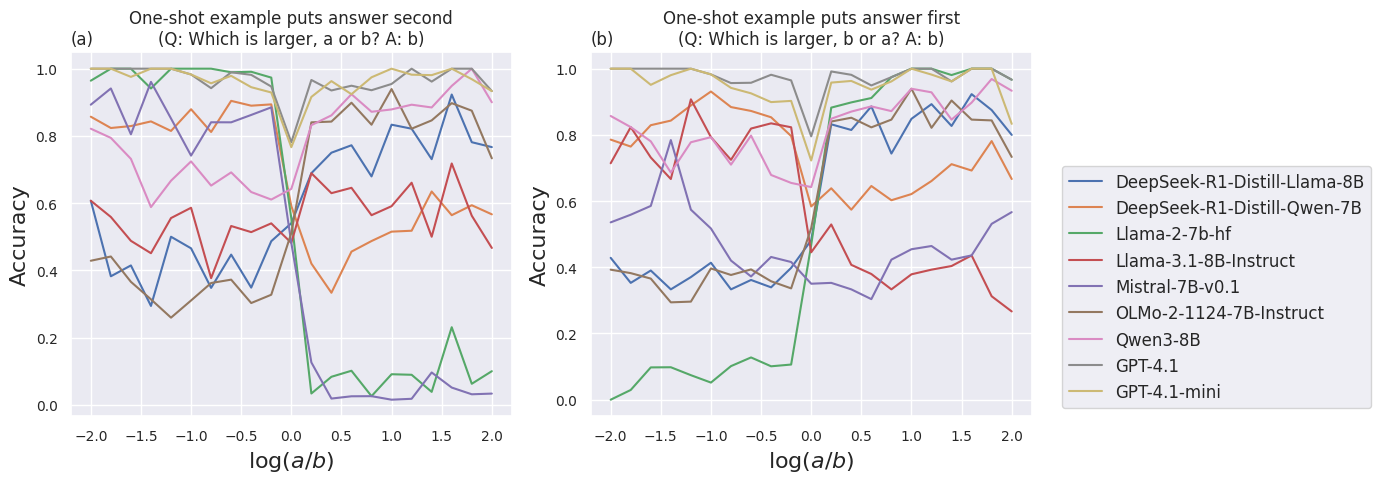

In [23]:
# camera-ready plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_order = [
    "DeepSeek-R1-Distill-Llama-8B",
    "DeepSeek-R1-Distill-Qwen-7B",
    "Llama-2-7b-hf",
    "Llama-3.1-8B-Instruct",
    "Mistral-7B-v0.1",
    "OLMo-2-1124-7B-Instruct",
    "Qwen3-8B",
    "GPT-4.1",
    "GPT-4.1-mini",
]

sns.lineplot(
    data=df_all[df_all["alt"] == False].groupby([
        "model",
        pd.cut(df_all[df_all["alt"] == False]["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right-0.1)
    ], observed=True)["comparison_correct"].mean().reset_index(),
    x="log_ratio",
    y="comparison_correct",
    hue="model",
    hue_order=model_order,
    ax=axes[0],
).set_title(
    "One-shot example puts answer second\n(Q: Which is larger, a or b? A: b)", fontsize=12
)

sns.lineplot(
    data=df_all[df_all["alt"] == True].groupby([
        "model",
        pd.cut(df_all[df_all["alt"] == True]["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right-0.1)
    ], observed=True)["comparison_correct"].mean().reset_index(),
    x="log_ratio",
    y="comparison_correct",
    hue="model",
    hue_order=model_order,
    ax=axes[1],
).set_title(
    "One-shot example puts answer first\n(Q: Which is larger, b or a? A: b)", fontsize=12
)

for idx, ax in enumerate(axes):
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("$\\log(a/b)$")

    label = chr(ord('a') + idx)  # 'a', 'b', 'c', ...
    ax.set_title(f'({label})', fontsize=12, loc='left')

axes[0].legend([]).remove()
axes[1].legend(bbox_to_anchor=(1.05, 0), loc='lower left')

plt.tight_layout()
fig_dir = os.path.join(ALL_FIG_DIR, "log_ratio_plot")
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, "alt_prompt.pdf"), bbox_inches="tight")
